In [1]:
# !uv pip install --system scikit-learn==1.5.2

try:
    from autogluon.tabular import TabularPredictor
except:
    !uv pip install autogluon
    from autogluon.tabular import TabularPredictor

## -- To use Foundtion models: data ~100k rows --
# !uv pip install autogluon.tabular[tabarena]

Using Python 3.12.13 environment at: /usr
Resolved 231 packages in 4.60s
⠙ Preparing packages... (0/52)
⠙ Preparing packages... (0/52)
⠙ Preparing packages... (0/52)
⠙ Preparing packages... (0/52)
python-discovery     ------------------------------     0 B/37.55 KiB
⠙ Preparing packages... (0/52)
python-discovery     ------------------------------ 14.78 KiB/37.55 KiB
⠙ Preparing packages... (0/52)
python-discovery     ------------------------------ 14.78 KiB/37.55 KiB
⠙ Preparing packages... (0/52)
python-discovery     ------------------------------ 14.78 KiB/37.55 KiB
⠙ Preparing packages... (0/52)
python-discovery     ------------------------------ 14.78 KiB/37.55 KiB
opentelemetry-api    ------------------------------ 14.77 KiB/58.61 KiB
⠙ Preparing packages... (0/52)
python-discovery     ------------------------------ 14.78 KiB/37.55 KiB
opentelemetry-api    ------------------------------ 14.77 KiB/58.61 KiB
⠙ Preparing packages... (0/52)
python-discovery     ----------------------

In [2]:
# %%capture cap
!uv pip install ipywidgets
!apt-get install -qq -y graphviz graphviz-dev && pip install -q pydot
!pip install -qq pygraphviz

Using Python 3.12.13 environment at: /usr
Checked 1 package in 121ms
Selecting previously unselected package libatk1.0-data.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ...
Unpack

In [3]:
import torch
import os
import pydot
import tensorflow as tf

import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from time import time, sleep
from itertools import combinations

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 100)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    "grid.alpha":        0.6,
    "grid.color":       '#2a2a4a',
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':  5,
    'SEED':   42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RED':    '\033[31m',
    'RESET':  '\033[0m',
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']}", end="")
print(f"{CFG['YELLOW']}YELLOW {CFG['RESET']} {CFG['RED']} RED {CFG['RESET']}")

CLASSIC  GREEN YELLOW   RED 


In [4]:
### Load Data ###
PATH = '/kaggle/input/competitions/playground-series-s6e8/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop('id', axis=1)

TARGET = "addicted_label"
TARGET

'addicted_label'

In [5]:
# import os
# import numpy as np
# import pandas as pd
## --Config settings --

data_path = "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-phone-outputs"

train_dict = {}
test_dict = {}

# --- Load Train Files
print("🟦 Loading train files: ", end="")
for dirname, _, filenames in os.walk(data_path):
    for i, filename in enumerate(sorted(filenames), 1):
        if filename.startswith("oof"):
            file = os.path.join(dirname, filename)
            col_name = filename.split("oof_")[1].replace(".npy", "")
            train_dict[col_name] = np.load(file).ravel()
            print('•', end="")

# --- Load Test Files
print("\n\n🟩 Loading test  files: ", end="")
for dirname, _, filenames in os.walk(data_path):
    for i, filename in enumerate(sorted(filenames), 1):
        if filename.startswith("test"):
            file = os.path.join(dirname, filename)
            col_name = filename.split("test_")[1].replace(".npy", "")
            test_dict[col_name] = np.load(file).ravel()
            print('•', end="")


# train_dict.pop("_age", None) 
# train_dict.pop("_stress_level", None) 

# test_dict.pop("_age", None) 
# test_dict.pop("_stress_level", None) 

# Create DataFrames separately
oof_df  = pd.DataFrame(train_dict)
pred_df = pd.DataFrame(test_dict)

## --- Exclude features if needed -------------------------
# selected = [c for c in oof_df.columns if "bartz" not in c]
# oof_df = oof_df[selected]
# pred_df = pred_df[selected]
## --------------------------------------------------------

MODEL_COLS = [*oof_df.columns]

print("\n\nShapes:")
print(f"Train shape: {oof_df.shape}")
print(f"Test shape:  {pred_df.shape}")

print('-'*50)
print(f"OOF  Null: {oof_df.isna().sum().sum()}")
print(f"TEST Null: {pred_df.isna().sum().sum()}")
print('-'*50)

display(oof_df.head())
display(pred_df.head())

🟦 Loading train files: •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

🟩 Loading test  files: •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

Shapes:
Train shape: (691369, 95)
Test shape:  (296302, 95)
--------------------------------------------------
OOF  Null: 0
TEST Null: 0
--------------------------------------------------


,Xgb_TabM_pseudo_968175,pseudo_xgbgrad_tabm_968446,ydf_globalFE38_cart_966988,ydf_globalFE38_random_967003,ydf_localFE38_cart_967222,ydf_localFE38_random_967221,xlearn_fe(56)_ffm_96644,xlearn_fe(56)_fm_964502,xlearn_fe(56)_lin_959945,xlearn_fe_cats(47)_ffm_9665,xlearn_fe_cats(47)_fm_964032,xlearn_fe_cats(47)_lin_960002,lgb_bag_967309,lgb_goss_967493,lgb_fe83bag_968207,lgb_fe83goss_968305,lgb_orig72_bag_96526,lgb_orig72_goss_965617,lgb_fe30_bag_964489,lgb_fe30_goss_964748,lgb_fe119bag_968121,lgb_fe119goss_968215,h2o56_best_966483,h2o56_stack_96638,fm_fastfm_als4_959328,fm_myfm_gibbs4_962623,bartz_BartP_fe77_96735,bartz_gbartP_fe77_964983,bartz_gbartR_fe77_964174,xgb_fe113_gbdt_968362,xgb_fe113_gbdt_968422,xgb_fe113_grad_968439,xgb_fe113_grad_968442,xgb_fe113_loss_968449,xgb_fe113_loss_968456,xgb_gbdt_967575,xgb_grad_967478,xgb_loss_967611,xgb_orig48_gbdt_965845,xgb_orig48_grad_965845,xgb_orig48_loss_965675,xgb_fe30_gbdt_965394,xgb_fe30_grad-al0.5_965253,xgb_fe30_loss_965124,xgb_fe128_gbdt_968506,xgb_fe128_gbdt_968522,xgb_fe128_grad_968562,xgb_fe128_loss_968512,xgb_fe128_loss_968546,tabpfn21_client_966928,hist77_967732,xtrees77_962227,logistic21_951738,logistic56_957494,logistic_cats5414_95959,mlp21_965052,mlp56_957757,tabnet_nd6_fe55_965653,sciKeras94_gelu_d5_9662,sciKeras94_relu_d5_966271,sciKeras94_selu_d5_966313,kerasFS_relu_958749,kerasFS_selu_d2_95816,kerasFS_silu_d2_957926,kerasFS_swish_d2_957845,cat_fe65_bayes_96823,cat_fe65_bern_967512,cat_fe65_loss_967883,cat_fe65_ord_bayes_968088,cat_origCV_bayes_964329,cat_origCV_bern_964655,cat_origCV_loss_964768,cat_origCV_ordered_bayes_964603,cat_orig_bayes_964499,cat_orig_bern_964441,cat_orig_loss_964218,cat_orig_ord_bayes_964188,cat_TE(84)_bayes_967292,cat_TE(84)_bern_966873,cat_TE(84)_loss_966969,cat_TE(84)_ord_bayes_96728,cat_TEboost(84)_bayes_967453,cat_TEboost(84)_bern_966654,cat_TEboost(84)_loss_966781,cat_TEboost(84)_ord_bayes_967064,cat_fe30_bayes_961019,cat_fe30_bern_960941,cat_fe30_loss_961287,cat_fe30_ord_bayes_959917,Pycat_bayes65_968127,Pycat_ben65_968059,Pylgb65_967029,Pyrealmlp65_968727,Pytabm65_968628,Pyxgb65_967109
0,0.937995,0.878594,0.950154,0.950919,0.945423,0.934637,0.864199,0.879669,0.917977,0.877176,0.877927,0.919874,0.915454,0.914336,0.929037,0.933555,0.928564,0.912257,0.807480,0.829360,0.924774,0.931268,0.955964,0.888379,0.599474,0.878609,0.821780,0.903530,0.795363,0.904534,0.919134,0.930243,0.907473,0.928166,0.915698,0.916961,0.916749,0.921490,0.925765,0.925765,0.925038,0.830043,0.847469,0.816273,0.919708,0.916697,0.924020,0.922322,0.925537,0.942398,0.897245,0.785489,0.897023,0.897463,0.933084,0.909194,0.840663,0.936162,0.938467,0.947179,0.955152,0.950017,0.954941,0.942793,0.939952,0.911568,0.927506,0.934916,0.901251,0.924729,0.909727,0.920071,0.911051,0.917942,0.910439,0.916275,0.900079,0.914678,0.924667,0.903542,0.912950,0.918213,0.931584,0.919574,0.925340,0.786051,0.771019,0.792440,0.748723,0.920575,0.909963,0.900086,0.875230,0.899673,0.786074
1,0.069150,0.045738,0.045805,0.045901,0.055880,0.051383,0.025222,0.021389,0.036611,0.023132,0.023779,0.040799,0.056969,0.034747,0.049763,0.049335,0.039857,0.024080,0.039762,0.043327,0.049497,0.047509,0.039637,0.044799,0.332217,0.043154,0.520663,0.027808,0.514646,0.041442,0.047644,0.047292,0.044381,0.044784,0.047010,0.038492,0.041976,0.043110,0.019434,0.019434,0.029103,0.026731,0.022758,0.027059,0.049952,0.048875,0.042222,0.044099,0.050224,0.061939,0.062301,0.087671,0.154608,0.132126,0.054907,0.072097,0.050248,0.088708,0.073370,0.075957,0.083988,0.033364,0.075747,0.033784,0.044287,0.048076,0.053916,0.039778,0.044520,0.026453,0.023125,0.023563,0.032155,0.030641,0.028174,0.027896,0.040632,0.045189,0.044296,0.037939,0.049598,0.045669,0.038132,0.036358,0.045547,0.026945,0.020437,0.020541,0.023959,0.059114,0.055596,0.045907,0.039852,0.060214,0.033760
2,0.213816,0.205619,0.215904,0.210522,0.216494,0.176245,0.234439,0.191727,0.221971,0.245119,0.189505,0.221626,0.224426,0.215137,0.193278,0.214515,0.250793,0.221246,0.3576

,Xgb_TabM_pseudo_968175,pseudo_xgbgrad_tabm_968446,ydf_globalFE38_cart_966988,ydf_globalFE38_random_967003,ydf_localFE38_cart_967222,ydf_localFE38_random_967221,xlearn_fe(56)_ffm_96644,xlearn_fe(56)_fm_964502,xlearn_fe(56)_lin_959945,xlearn_fe_cats(47)_ffm_9665,xlearn_fe_cats(47)_fm_964032,xlearn_fe_cats(47)_lin_960002,lgb_bag_967309,lgb_goss_967493,lgb_fe83bag_968207,lgb_fe83goss_968305,lgb_orig72_bag_96526,lgb_orig72_goss_965617,lgb_fe30_bag_964489,lgb_fe30_goss_964748,lgb_fe119bag_968121,lgb_fe119goss_968215,h2o56_best_966483,h2o56_stack_96638,fm_fastfm_als4_959328,fm_myfm_gibbs4_962623,bartz_BartP_fe77_96735,bartz_gbartP_fe77_964983,bartz_gbartR_fe77_964174,xgb_fe113_gbdt_968362,xgb_fe113_gbdt_968422,xgb_fe113_grad_968439,xgb_fe113_grad_968442,xgb_fe113_loss_968449,xgb_fe113_loss_968456,xgb_gbdt_967575,xgb_grad_967478,xgb_loss_967611,xgb_orig48_gbdt_965845,xgb_orig48_grad_965845,xgb_orig48_loss_965675,xgb_fe30_gbdt_965394,xgb_fe30_grad-al0.5_965253,xgb_fe30_loss_965124,xgb_fe128_gbdt_968506,xgb_fe128_gbdt_968522,xgb_fe128_grad_968562,xgb_fe128_loss_968512,xgb_fe128_loss_968546,tabpfn21_client_966928,hist77_967732,xtrees77_962227,logistic21_951738,logistic56_957494,logistic_cats5414_95959,mlp21_965052,mlp56_957757,tabnet_nd6_fe55_965653,sciKeras94_gelu_d5_9662,sciKeras94_relu_d5_966271,sciKeras94_selu_d5_966313,kerasFS_relu_958749,kerasFS_selu_d2_95816,kerasFS_silu_d2_957926,kerasFS_swish_d2_957845,cat_fe65_bayes_96823,cat_fe65_bern_967512,cat_fe65_loss_967883,cat_fe65_ord_bayes_968088,cat_origCV_bayes_964329,cat_origCV_bern_964655,cat_origCV_loss_964768,cat_origCV_ordered_bayes_964603,cat_orig_bayes_964499,cat_orig_bern_964441,cat_orig_loss_964218,cat_orig_ord_bayes_964188,cat_TE(84)_bayes_967292,cat_TE(84)_bern_966873,cat_TE(84)_loss_966969,cat_TE(84)_ord_bayes_96728,cat_TEboost(84)_bayes_967453,cat_TEboost(84)_bern_966654,cat_TEboost(84)_loss_966781,cat_TEboost(84)_ord_bayes_967064,cat_fe30_bayes_961019,cat_fe30_bern_960941,cat_fe30_loss_961287,cat_fe30_ord_bayes_959917,Pycat_bayes65_968127,Pycat_ben65_968059,Pylgb65_967029,Pyrealmlp65_968727,Pytabm65_968628,Pyxgb65_967109
0,0.999541,0.931176,0.996937,0.996915,0.997699,0.997824,0.999654,0.999692,0.999261,0.999615,0.999675,0.999291,0.801014,0.907571,0.999539,0.999596,0.999013,0.999298,0.999721,0.999664,0.999546,0.999577,0.998972,0.999167,0.734283,0.999985,0.821135,0.924288,0.785337,0.999801,0.999697,0.999718,0.999751,0.999613,0.999597,0.896979,0.882210,0.873930,0.999541,0.999541,0.999372,0.999807,0.999774,0.999756,0.999735,0.999718,0.999770,0.999560,0.999618,0.999867,0.999359,0.997053,0.993212,0.993958,0.999847,0.999130,0.997268,0.997911,0.999236,0.999149,0.999055,0.999346,0.998177,0.998284,0.999110,0.999618,0.999147,0.999398,0.999689,0.999620,0.998715,0.998654,0.999594,0.999726,0.999541,0.998619,0.999692,0.999637,0.999704,0.999616,0.999825,0.999336,0.999515,0.999301,0.999437,0.999470,0.999470,0.999593,0.999330,0.901607,0.879457,0.999660,0.995524,0.999938,0.960718
1,0.954756,0.311223,0.958938,0.958572,0.954481,0.955641,0.973138,0.971856,0.973454,0.974374,0.969989,0.972998,0.572207,0.625163,0.962628,0.964832,0.966002,0.972515,0.964098,0.957344,0.962317,0.965238,0.941182,0.950040,0.683303,0.982311,0.647420,0.426492,0.680942,0.968830,0.961022,0.968805,0.964695,0.966784,0.967254,0.659597,0.655033,0.627620,0.933467,0.933467,0.949821,0.948514,0.936257,0.942105,0.960294,0.959164,0.963995,0.962091,0.961021,0.969143,0.966999,0.896896,0.969108,0.947453,0.977120,0.972922,0.917905,0.968151,0.967673,0.961477,0.959278,0.925055,0.887178,0.895770,0.882483,0.978357,0.974093,0.970641,0.976068,0.962422,0.962704,0.966912,0.956533,0.950018,0.956774,0.955321,0.953075,0.966193,0.963080,0.962690,0.962060,0.970164,0.969907,0.970083,0.975413,0.952325,0.963617,0.952249,0.942638,0.291703,0.302356,0.975133,0.949659,0.962170,0.312834
2,0.763769,0.562221,0.861249,0.861743,0.804685,0.804142,0.887043,0.751476,0.827622,0.877572,0.739596,0.823810,0.715793,0.780697,0.750469,0.771848,0.879352,0.896840,0.9447

In [6]:
## -- Confirm feature name consistency --
for (a, b) in zip(oof_df.columns, pred_df.columns):
    if a == b:
        print(f"{CFG['GREEN']}✓ ", end="")
    else:
        print(f"{CFG['RED']}✘ ", end="")

✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ 

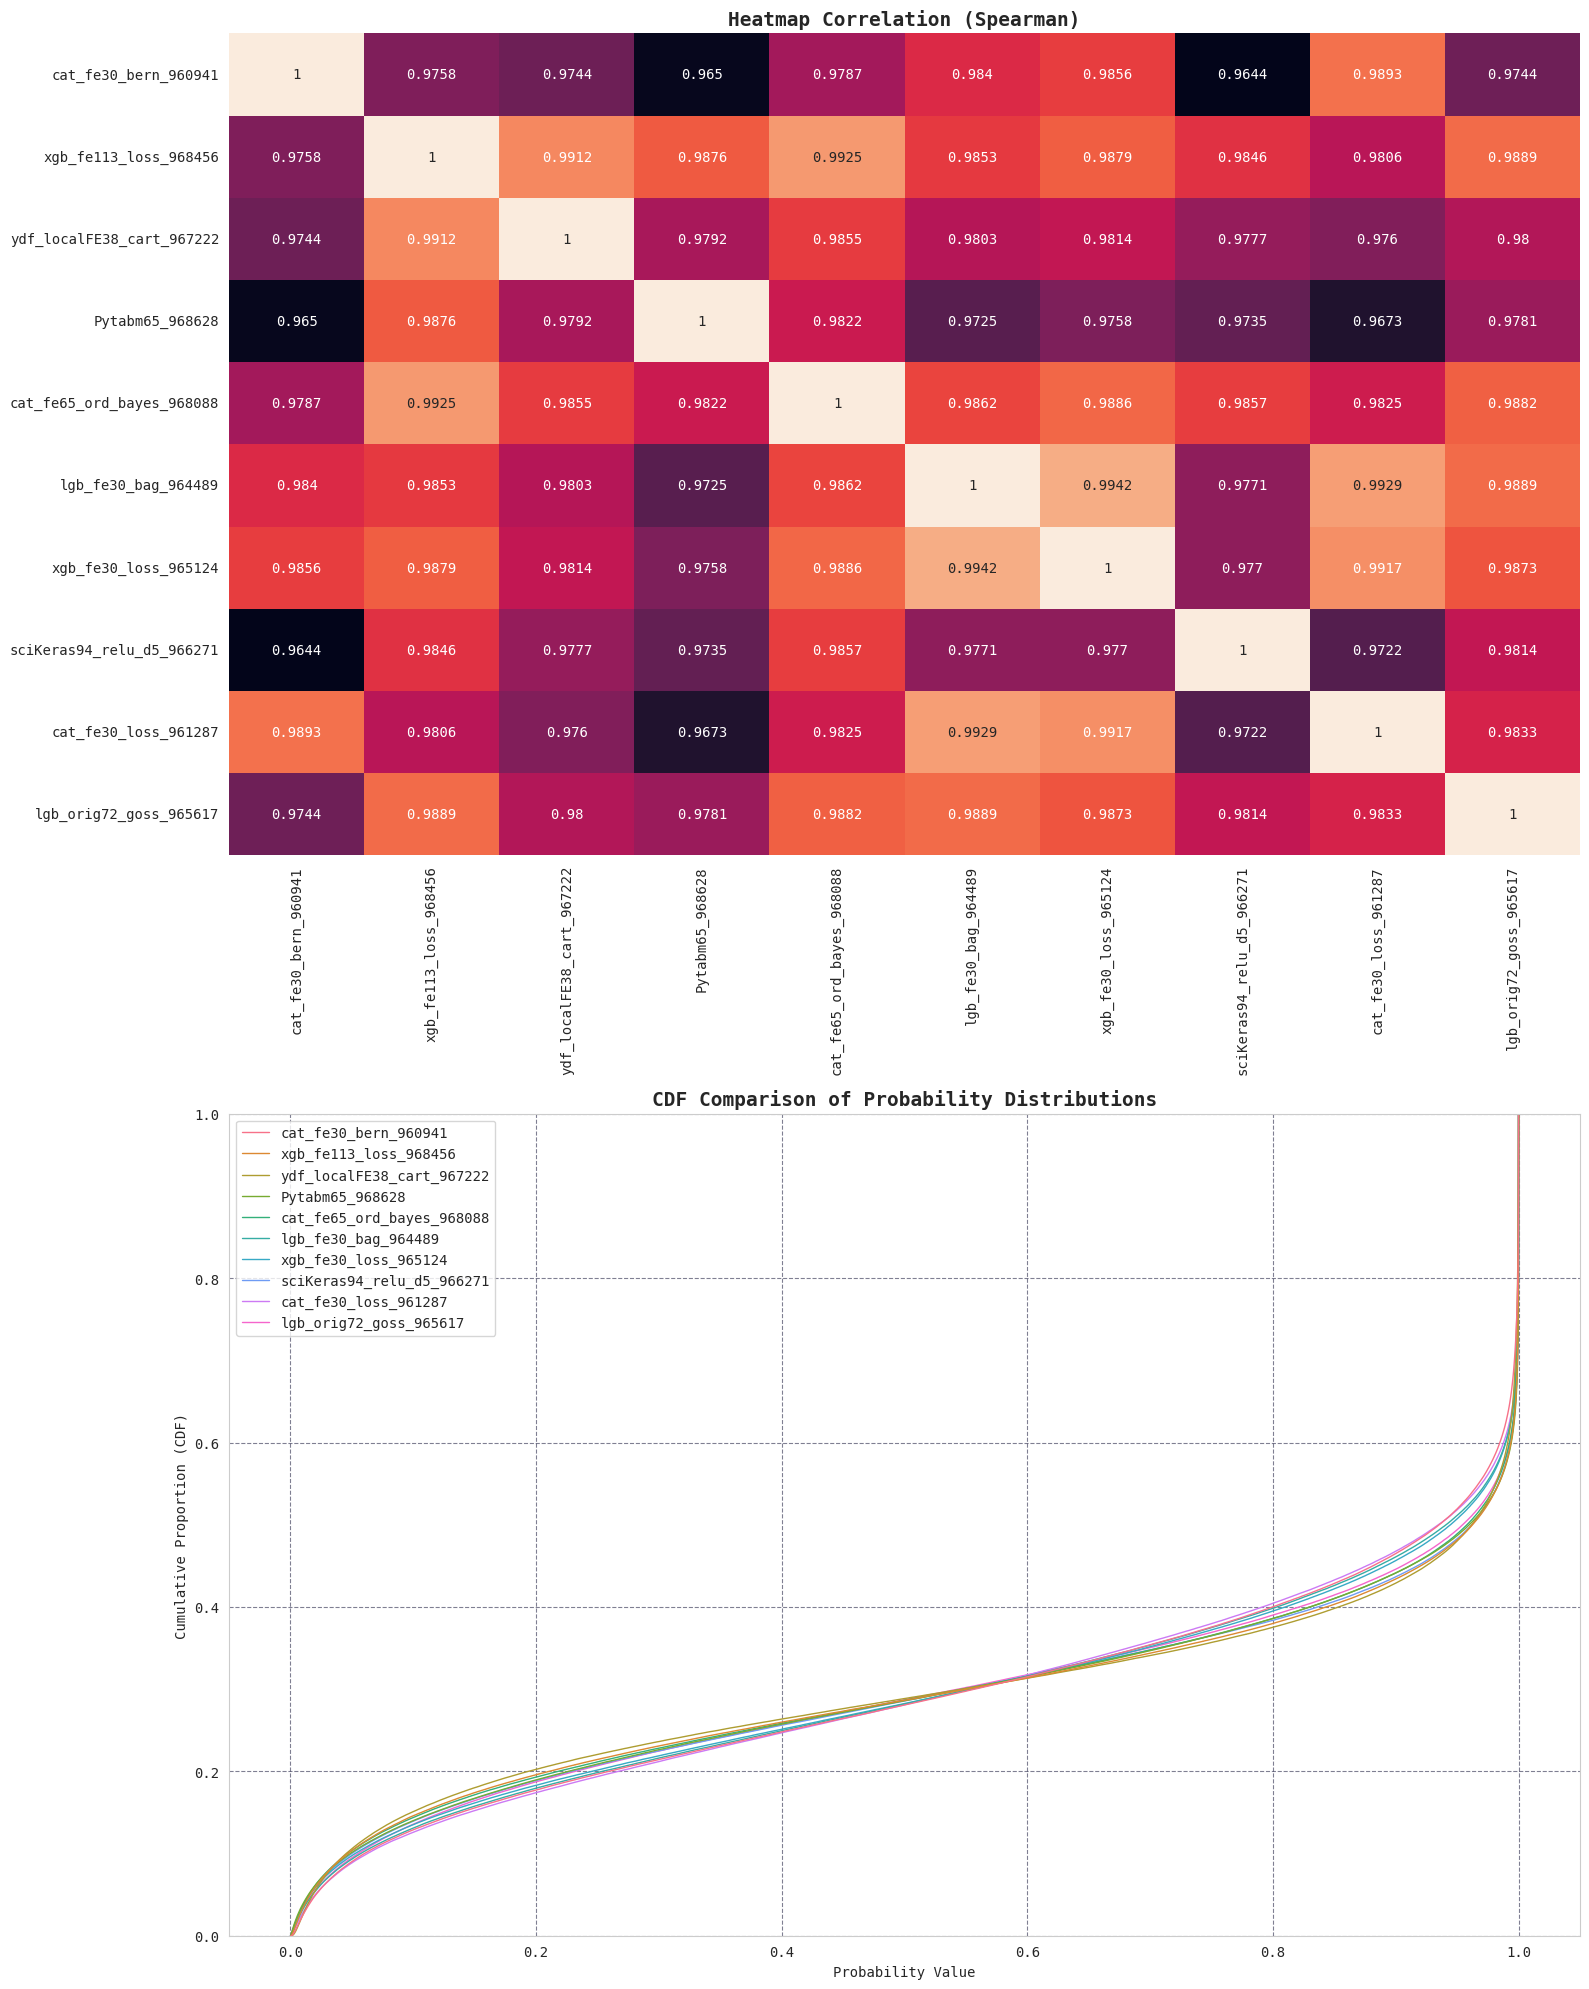

CPU times: user 27.4 s, sys: 1.24 s, total: 28.6 s
Wall time: 28.6 s


In [7]:
%%time

sub_ = oof_df.sample(n=10, axis="columns") # select by columns

# if len(sub_.columns) > 1:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 20))
sns.heatmap(sub_.corr("spearman"), annot=True, fmt=".4g", cbar=False, ax=ax1)
ax1.set_title("Heatmap Correlation (Spearman)", fontsize=14, fontweight='bold')

sns.ecdfplot(data=sub_, linewidth=1, ax=ax2) # legend=False, 
ax2.set_title("CDF Comparison of Probability Distributions", fontsize=14, fontweight='bold')
ax2.set_xlabel("Probability Value")
ax2.set_ylabel("Cumulative Proportion (CDF)") 
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("oof_heatmap_cdf_plot")
plt.show()

In [8]:
MODELS_PATH = "/kaggle/working/ag_addicted_models/"
# !rm -r {MODELS_PATH}

In [9]:
from autogluon.tabular import TabularPredictor

In [10]:
## -- RUN 1: Use train data -- best_quality_dyn_True
predictor = TabularPredictor(
                label = TARGET,
         problem_type = "binary",
          eval_metric = "roc_auc",
                 path = MODELS_PATH,
    ).fit(
                   train_data = pd.concat([oof_df, train[TARGET]], axis=1),
                      presets = "best_quality", # "best_quality", "best_quality_v150"
                num_bag_folds = 5,
             dynamic_stacking = False,
             num_stack_levels = 1,
                   time_limit = 3600*11,
                   # auto_stack = False,
                 # num_bag_sets = 2,
                  # ag_args_fit = {'num_cpus': os.cpu_count()},
) 

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat May 30 15:40:53 UTC 2026
CPU Count:          4
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       26.69 GB / 31.35 GB (85.2%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 39600s
AutoGluon will save models to "/kaggle/working/ag_addicted_models"
Train Data Rows:    691369
Train Data Columns: 95
Label Column:       addicted_label
Problem Type:       binary
Preprocessing data...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting Aut

In [11]:
## -- Get Summary -- 
print(f"-> Total models : {len(predictor.model_names())}")
print(f"-> Best model   : {predictor.model_best}\n") 

## -- RUN 1 RESULTS -- 
leaderboard = predictor.leaderboard(silent=True)
leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

-> Total models : 44
-> Best model   : WeightedEnsemble_L3



,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,0.969457,roc_auc,576.005112,28229.467537,0.120660,129.472531,3,True,44
1,WeightedEnsemble_L2,0.969453,roc_auc,205.880620,3049.136374,0.115005,76.614075,2,True,26
2,NeuralNetFastAI_r102_BAG_L1,0.969413,roc_auc,3.118686,733.606403,3.118686,733.606403,1,True,22
3,NeuralNetFastAI_BAG_L1,0.969390,roc_auc,5.113389,1254.435311,5.113389,1254.435311,1,True,8
4,LightGBM_r96_BAG_L2,0.969387,roc_auc,566.004711,26321.782297,38.820234,317.228661,2,True,43
5,LightGBMXT_BAG_L2,0.969387,roc_auc,536.778894,26176.655658,9.594417,172.102022,2,True,27
6,LightGBM_r131_BAG_L2,0.969379,roc_auc,568.966805,26453.179414,41.782328,448.625778,2,True,40
7,NeuralNetFastAI_BAG_L2,0.969376,roc_auc,533.544912,27399.170495,6.360435,1394.616859,2,True,34
8,LightGBM_r96_BAG_L1,0.969371,roc_auc,197.533539,984.480586,197.533539,984.480586,1,True,17
9,XGBoost_BAG_L2,0.969369,roc_auc,532.484302,26268.940576,5.299825,264.386940,2,True,35


In [12]:
# ## -- RUN 2: Use original data as extra learning input --
# predictor.fit_pseudolabel(
#                 orig,
#                 use_ensemble = True,
#                 fit_ensemble = True,
#                 time_limit   = 3600*5,
# )

In [13]:
# ## -- Get Summary -- 
# print(f"-> Total models : {len(predictor.model_names())}")
# print(f"-> Best model   : {predictor.model_best}\n") 

# ## -- RUN 2 RESULTS -- 
# leaderboard = predictor.leaderboard(silent=True)
# leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

In [14]:
## -- Create folder directory to save predictions --
SAVE_PATH = "/kaggle/working/ag_addicted_preds/"
FILE_NAME = "ag_addicted.parquet"
!mkdir {SAVE_PATH}

In [15]:
# %%time
# ## -- Generate predictions for all models --
# ag_multi_test = predictor.predict_proba_multi(pred_df, as_multiclass=False)

# ## -- Save TEST predictions of all models --
# final_test_data = {}
# DESC = "Exporting TEST predictions"

# for k, v in tqdm(ag_multi_test.items(), desc=DESC):
#     k_renamed = k.replace('_', '')
#     final_test_data[k_renamed] = v

# file_name = f"{SAVE_PATH}test_{FILE_NAME}"

# final_test_df = pd.DataFrame(final_test_data)
# final_test_df.to_parquet(file_name, index=False)
# final_test_df.head()

In [16]:
# %%time

# ## -- Get OOF predictions of all models --
# ag_multi_oof_preds = {}
# DESC1 = "Processing OOF probabilities"

# for model in tqdm(predictor.model_names(), desc=DESC1):
#     ag_multi_oof_preds[model] = predictor.predict_proba_oof(
#                                              model = model,
#                                         train_data = pd.concat([oof_df, train[TARGET]], axis=1),
#                                      as_multiclass = False,
#                                 )

# final_oof_data = {}
# DESC2 = "Exporting OOF predictions"

# for k, v in tqdm(ag_multi_oof_preds.items(), desc=DESC2):
#     k_renamed = k.replace('_', '')
#     final_oof_data[k_renamed] = v

# file_name = f"{SAVE_PATH}oof_{FILE_NAME}"

# final_oof_df = pd.DataFrame(final_oof_data)
# final_oof_df.to_parquet(file_name, index=False)
# final_oof_df.head()

In [17]:
## -- SUBMISSION --
final_preds = predictor.predict_proba(pred_df, as_multiclass=False)
final_score = np.round(leaderboard.score_val.max(), 6)

n = f"submit_autogluon_stack_{str(final_score).split('.')[1]}_.csv"
submit[TARGET] = final_preds
submit.to_csv(n, index=False)

print("Submission file exported -> ", n)
submit

Submission file exported ->  submit_autogluon_stack_969457_.csv


,id,addicted_label
0,691369,0.995331
1,691370,0.976380
2,691371,0.857323
3,691372,0.924934
4,691373,0.992409
...,...,...
296297,987666,0.999639
296298,987667,0.624278
296299,987668,0.117264
296300,987669,0.832644


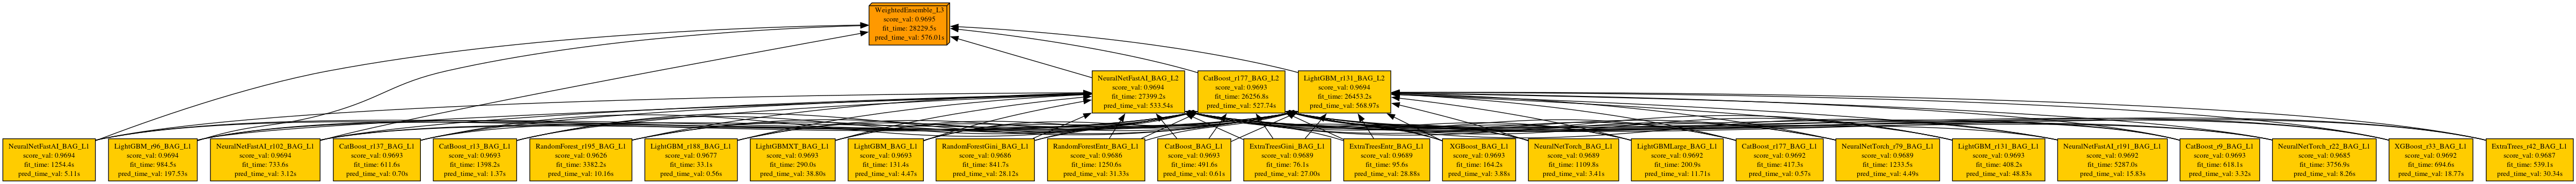

In [18]:
predictor.plot_ensemble_model(filename="ensemble_model.png")
display(Image(f"{MODELS_PATH}ensemble_model.png"))

In [19]:
# !zip -r /kaggle/working/AG_accident_models /kaggle/working/AG_accident_models.zip
# !zip -r {FOLDER}{NAME_EXT}.zip /kaggle/working/{FOLDER}{NAME_EXT}

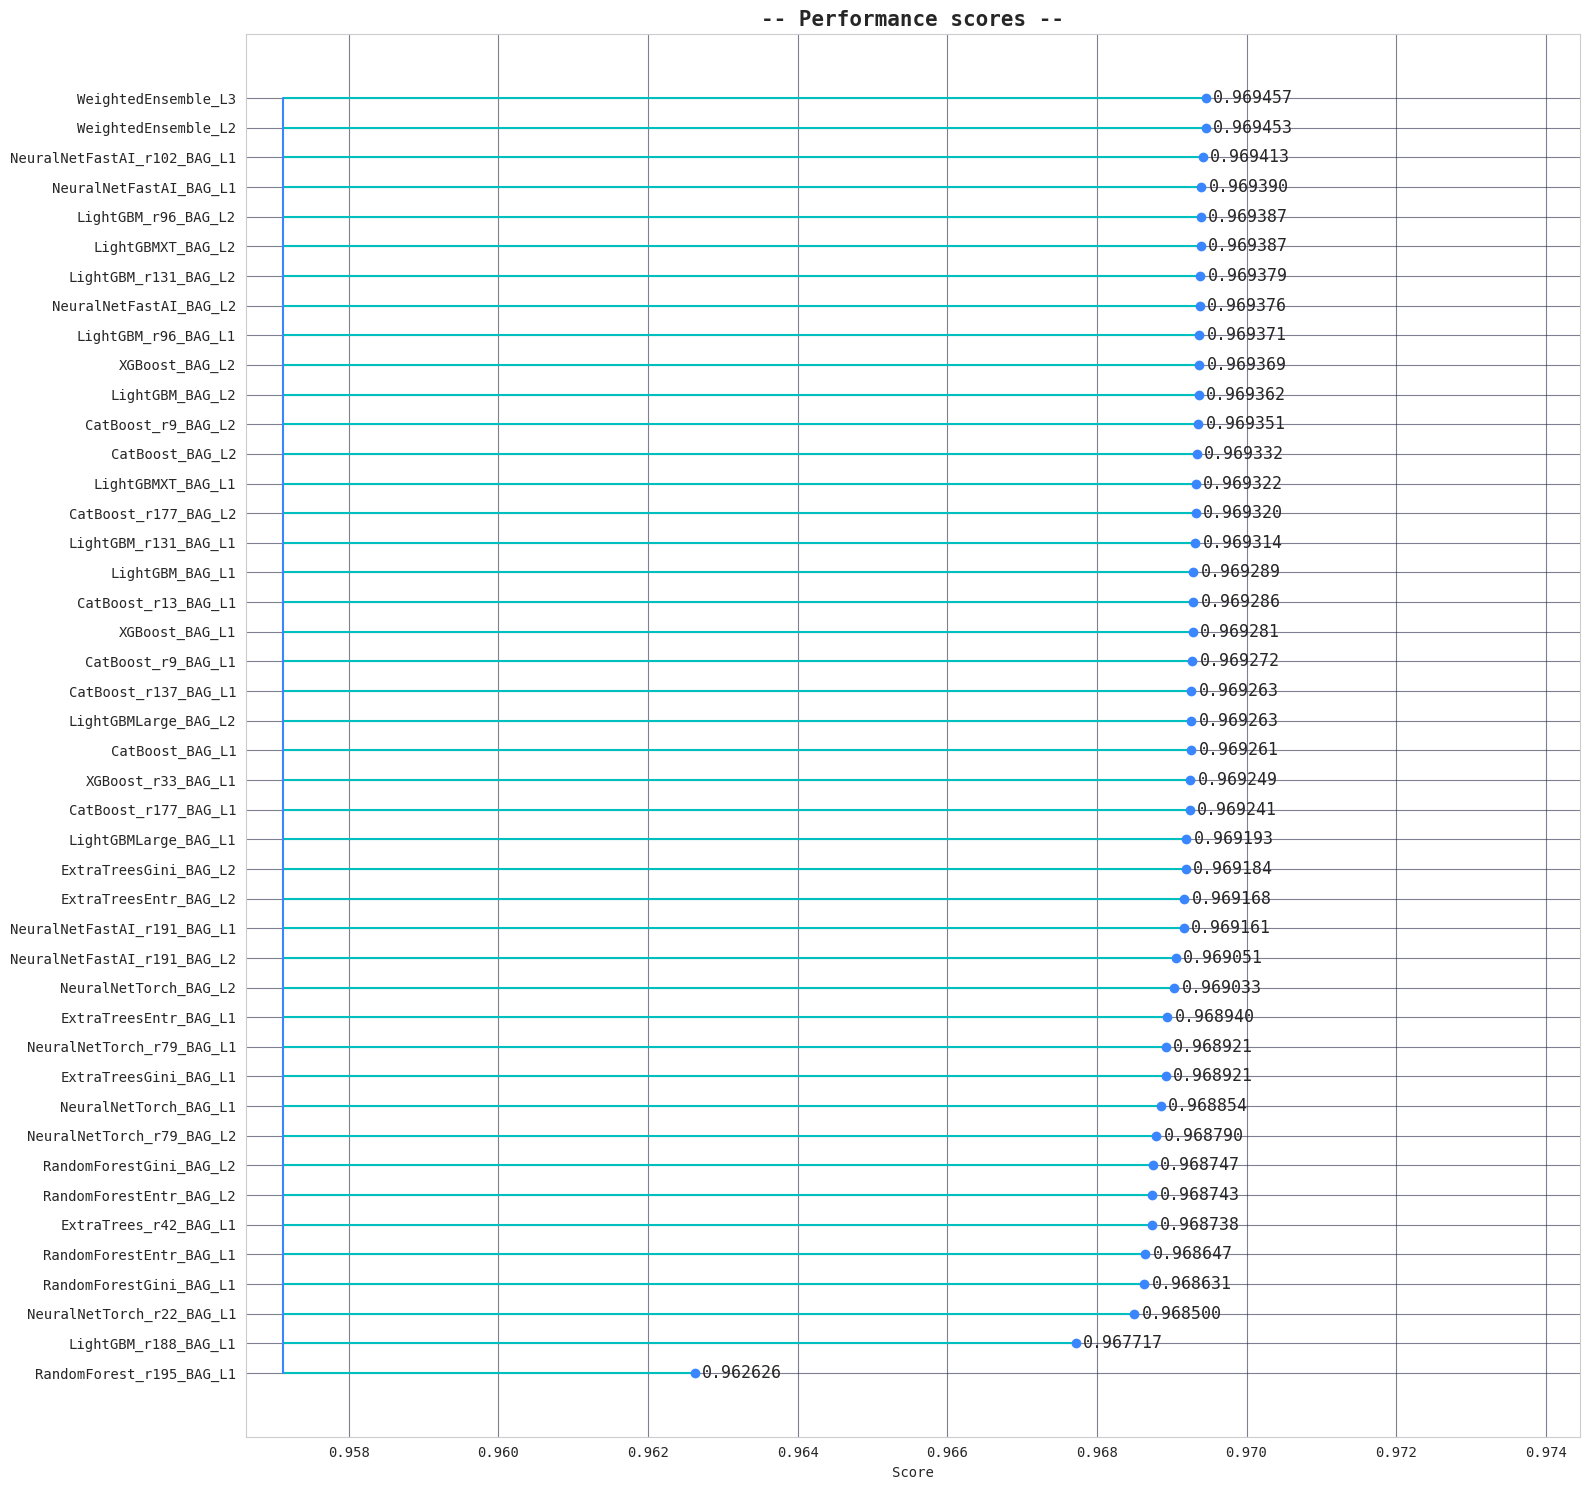

In [20]:
## -- Extract model scores --
result_ = dict(zip(leaderboard['model'], leaderboard['score_val']))
result_df = pd.DataFrame.from_dict(result_, orient='index').sort_values(0)

max_score = result_df.max().item()
min_score = result_df.min().item()

## -- PLOT MODELS & SCORES --
plt.figure(figsize=(16, 15))
plt.stem(
    result_df.index,
    result_df[0],
    orientation = 'horizontal',
    bottom = min_score - 0.0055,
    markerfmt = 'C3o'
)
plt.xlim(min_score - 0.006, max_score + 0.005)
plt.xlabel('Score')
plt.title('-- Performance scores --', fontsize=15, fontweight='bold')

for i, value in enumerate(result_df[0]):
    plt.text(value+1e-4, i, f'{abs(value):.6f}', ha='left', va='center', fontdict=dict(size=12))

plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

In [21]:
# predictor.model_names()

In [22]:
# ## -- Permutation Feature Importances --
# feat_imp = predictor.feature_importance(
#                         data = X_test,
#                         # time_limit = 3600,
#                         # model = 'LightGBM_BAG_L1',
#                         # features = None,
#                         # feature_stage = 'transformed',
#                         # subsample_size = 5000,
#                         # num_shuffle_sets = 10,
#                         # include_confidence_band = True,
#                         confidence_level = 0.95,
#                         # silent = False
# ) 

# feat_imp.style.background_gradient(subset=["importance"], cmap="Spectral")

# plt.figure(figsize=(18, 35))
# sns.barplot(data=feat_imp, y=feat_imp.index, x=feat_imp.importance)
# plt.tick_params(axis='y', which='major', labelcolor='r')
# plt.title("Top Features by Permutation")
# plt.tight_layout()
# plt.show()

In [23]:
print(f"""
{'-'*48}
{'█'*5} | - AUTOGLUON NOTEBOOK COMPLETE! - | {'█'*5}
{'-'*48}
""")


------------------------------------------------
█████ | - AUTOGLUON NOTEBOOK COMPLETE! - | █████
------------------------------------------------



In [24]:
## -- OPTIONAL: Clear stored files in memory --
!rm -r {MODELS_PATH}